<a href="https://colab.research.google.com/github/SarahSAH02/Dat255_prosjekt/blob/main/CNN_modell_ferdig.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/archive (4).zip"
extract_path = "/content/chexpert"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


print("done!")

Mounted at /content/drive
done!



**IMPORTS**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import f1_score, roc_auc_score, roc_curve

**DATASET & PREPROCRSSING**

We are using the Chexpert dataset with 14 labels. Missing values (NaN) and uncertain labels (-1) are mapped to 0.

In [3]:


label_values = [
    'Atelectasis','Cardiomegaly','Consolidation','Edema',
    'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
    'Lung Opacity','No Finding','Pleural Effusion',
    'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
]


train_df = pd.read_csv(os.path.join(extract_path, "train.csv"))
valid_df = pd.read_csv(os.path.join(extract_path, "valid.csv"))


train_df['Path'] = train_df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
valid_df['Path'] = valid_df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)

train_df[label_values] = train_df[label_values].fillna(0).replace(-1, 0)
valid_df[label_values] = valid_df[label_values].fillna(0).replace(-1, 0)

train_df = train_df[['Path'] + label_values]
valid_df = valid_df[['Path'] + label_values]



print(train_df.head())

                                          Path  Atelectasis  Cardiomegaly  \
0  train/patient00001/study1/view1_frontal.jpg          0.0           0.0   
1  train/patient00002/study2/view1_frontal.jpg          0.0           0.0   
2  train/patient00002/study1/view1_frontal.jpg          0.0           0.0   
3  train/patient00002/study1/view2_lateral.jpg          0.0           0.0   
4  train/patient00003/study1/view1_frontal.jpg          0.0           0.0   

   Consolidation  Edema  Enlarged Cardiomediastinum  Fracture  Lung Lesion  \
0            0.0    0.0                         0.0       0.0          0.0   
1            0.0    0.0                         0.0       1.0          0.0   
2            0.0    0.0                         0.0       1.0          0.0   
3            0.0    0.0                         0.0       1.0          0.0   
4            0.0    1.0                         0.0       0.0          0.0   

   Lung Opacity  No Finding  Pleural Effusion  Pleural Other  Pneumo

**DATA ANALYSIS**

Analyzing the dataset to understand label distribution and class imbalance, which is common in medical dataset

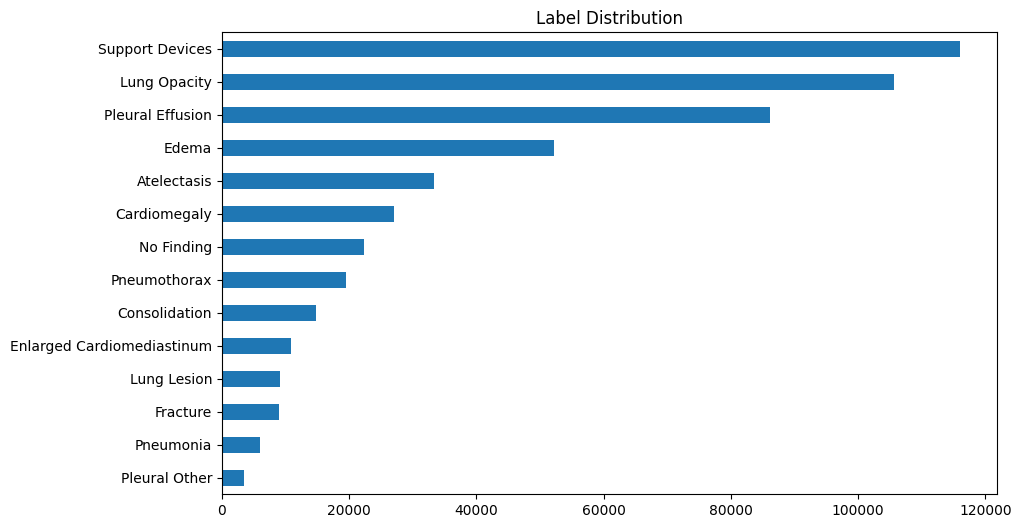

In [4]:
label_counts = train_df[label_values].sum().sort_values()

plt.figure(figsize=(10,6))
label_counts.plot(kind='barh')
plt.title("Label Distribution")
plt.show()

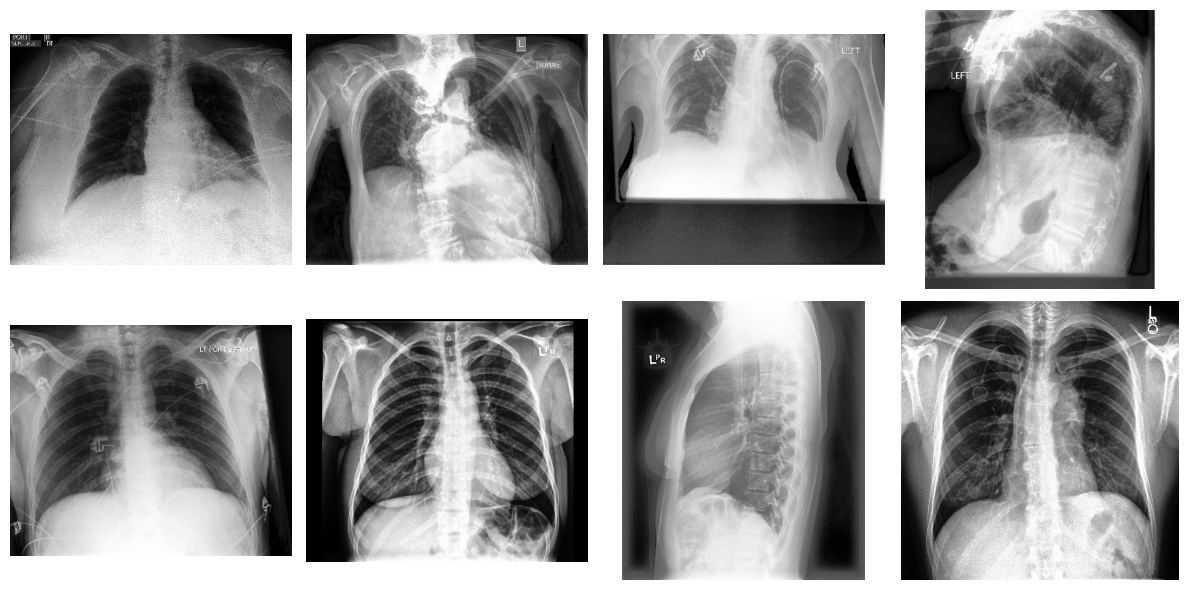

In [5]:
fig, axes = plt.subplots(2,4, figsize=(12,6))

for i, ax in enumerate(axes.flatten()):

    full_img_path = os.path.join(extract_path, train_df.iloc[i]['Path'])
    img = Image.open(full_img_path).convert("RGB")
    ax.imshow(img, cmap='gray')
    ax.axis("off")

plt.tight_layout()
plt.show()

**DATA TRANSFORM**

Using data augmentation and resizing images to improve generalization and reduce overfitting.

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

**DATASET**




In [7]:
class CheXpertDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_img_path = os.path.join(extract_path, row['Path'])
        img = Image.open(full_img_path).convert("RGB")
        labels = row[1:].values.astype(np.float32)

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(labels)

**DATALOADER**

Dataloader are used to load data in batches

In [8]:
train_dataset = CheXpertDataset(train_df, train_transform)
valid_dataset = CheXpertDataset(valid_df, valid_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

**MODEL ARCHITECTURES**

Custum CNN

In [9]:

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(32*56*56, 14)

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

**LOSS & OPTIMIZIER**

Binary Cross Entropy with logits is used for multi-label classification.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pos_weight = torch.ones(14).to(device)

L_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(device)

cuda


In [11]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 14])


In [12]:
img, label = train_dataset[0]
print(img.shape, label.shape)

torch.Size([3, 224, 224]) torch.Size([14])


In [13]:
print(train_df.iloc[0]['Path'])
print(os.path.exists(os.path.join(extract_path, train_df.iloc[0]['Path'])))

train/patient00001/study1/view1_frontal.jpg
True


**Training of models**

In [14]:
print("Train size:", len(train_df))
print("Valid size:", len(valid_df))

Train size: 223414
Valid size: 234


Models are trained using Adam optimizer with weight decay.

In [15]:
def train_model(model, epochs=3):
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.3, patience=2
    )

    train_losses = []
    val_losses = []

    best_f1 = 0

    for epoch in range(epochs):


        model.train()
        running_loss = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = L_func(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if i % 50 == 0:
                print(f"Epoch {epoch+1} Batch {i}/{len(train_loader)} Loss {loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)



        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in valid_loader: # Changed val_loader to valid_loader
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = L_func(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(valid_loader) # Changed val_loader to valid_loader
        val_losses.append(val_loss)

        scheduler.step(val_loss)



        print("\nEvaluation:")
        f1, auc = evaluate(model)


        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_loss:.4f}")
        print(f"F1 Score:   {f1:.4f}")
        print(f"AUC:        {auc:.4f}")



        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), "best_model_cnn.pth")
            print("Beste modell lagret!")

    return train_losses, val_losses

**EVALUATION**

Model performance is evaluated using Macro F1-score and ROC-AUC. Threshold tuning is applied to improve classification performance.

In [16]:
def get_preds(model):
    model.eval()
    preds,targets=[],[]
    with torch.no_grad():
        for images,labels in valid_loader:
            images=images.to(device)
            outputs=torch.sigmoid(model(images)).cpu().numpy()
            preds.append(outputs)
            targets.append(labels.numpy())
    return np.vstack(preds), np.vstack(targets)

In [17]:
def find_thresholds(preds,targets):
    thresholds=[]
    for i in range(14):
        best_t,best_f1=0.5,0
        for t in np.arange(0.1,0.9,0.05):
            f1=f1_score(targets[:,i], (preds[:,i]>t).astype(int))
            if f1>best_f1:
                best_f1, best_t = f1,t
        thresholds.append(best_t)
    return thresholds

In [18]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

def evaluate(model):
    preds, targets = get_preds(model)

    thresholds = []

    for i in range(14):
        best_t = 0.5
        best_f1 = 0

        for t in np.arange(0.1, 0.9, 0.05):
            pred_bin = (preds[:, i] > t).astype(int)
            f1 = f1_score(targets[:, i], pred_bin, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds.append(best_t)

    preds_bin = np.zeros_like(preds)

    for i in range(14):
        preds_bin[:, i] = (preds[:, i] > thresholds[i]).astype(int)

    f1 = f1_score(targets, preds_bin, average="macro", zero_division=0)

    valid_auc = []
    for i in range(14):
        if len(np.unique(targets[:, i])) > 1:
            valid_auc.append(
                roc_auc_score(targets[:, i], preds[:, i])
            )

    auc = np.mean(valid_auc)

    print("Macro F1:", f1)
    print("Mean AUC:", auc)

    return f1, auc

**RUN BASELINE**

In [32]:
#Trener modelle (lagrer beste automatisk)
model = SimpleCNN()
train_model(model, epochs=3)

# Laster beste modell
model.load_state_dict(torch.load("best_model_cnn.pth")) # Corrected filename
model.to(device)

print("Beste modell lastet ned!")

#Evaluerer beste modell
evaluate(model)

#Lagrer final modell
torch.save(model.state_dict(), "cnn_modell.pth")
print("Final modell lagret!")

Epoch 1 Batch 0/6982 Loss 0.6968
Epoch 1 Batch 50/6982 Loss 0.3240
Epoch 1 Batch 100/6982 Loss 0.3807
Epoch 1 Batch 150/6982 Loss 0.3706
Epoch 1 Batch 200/6982 Loss 0.3563


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_3484/2933257921.py", line 3, in <cell line: 0>
    train_model(model, epochs=3)
  File "/tmp/ipykernel_3484/519352075.py", line 21, in train_model
    for i, (images, labels) in enumerate(train_loader):
                               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 801, in _next_data
    data = self._dataset_fetcher.fetch(index)  # may raise StopIteration
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx 

TypeError: object of type 'NoneType' has no len()

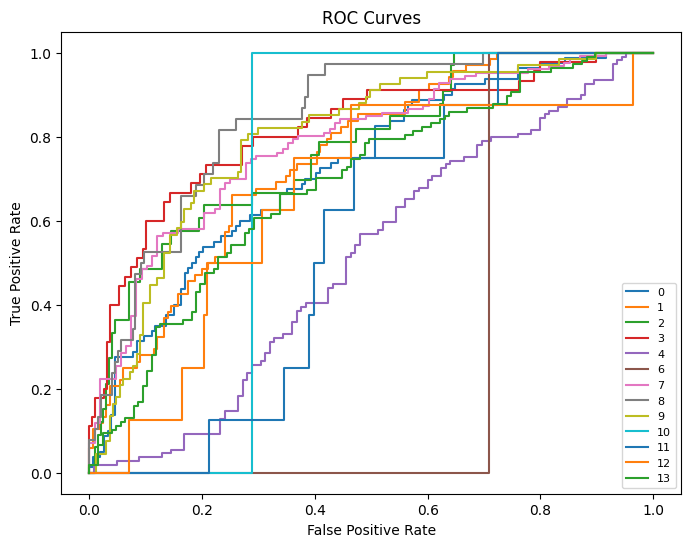

In [20]:
from sklearn.metrics import roc_curve

preds, targets = get_preds(model)

plt.figure(figsize=(8,6))

for i in range(14):
    if len(np.unique(targets[:, i])) > 1:
        fpr, tpr, _ = roc_curve(targets[:, i], preds[:, i])
        plt.plot(fpr, tpr, label=f"{i}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right", fontsize=8)
plt.show()

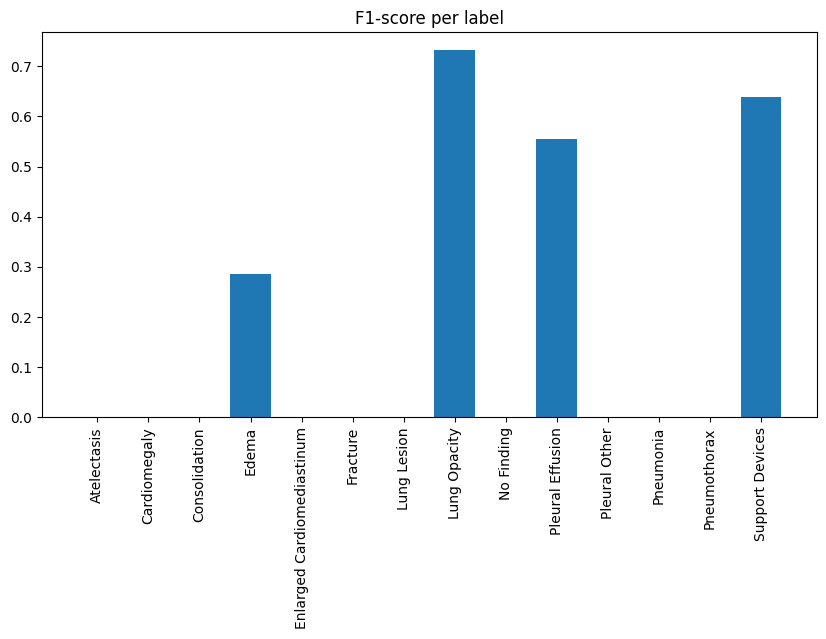

In [21]:
f1_scores = []

for i in range(14):
    pred_bin = (preds[:, i] > 0.5).astype(int)
    f1 = f1_score(targets[:, i], pred_bin, zero_division=0)
    f1_scores.append(f1)

plt.figure(figsize=(10,5))
plt.bar(range(14), f1_scores)
plt.xticks(range(14), label_values, rotation=90)
plt.title("F1-score per label")
plt.show()

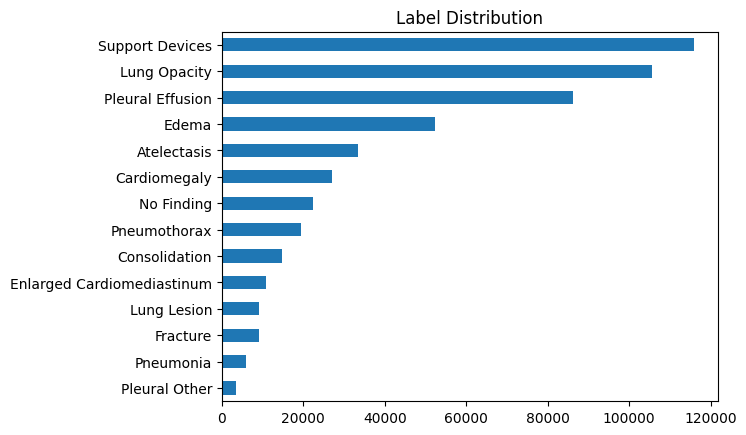

In [22]:
train_df[label_values].sum().sort_values().plot(kind='barh')
plt.title("Label Distribution")
plt.show()

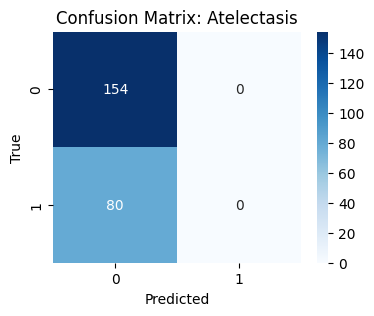

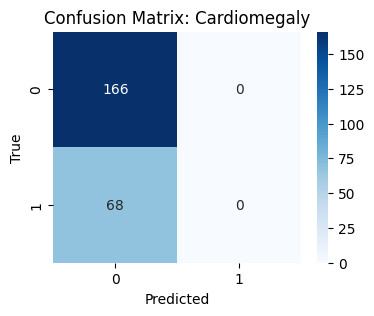

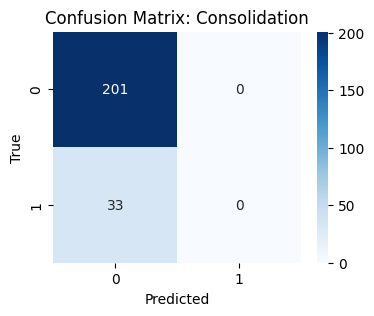

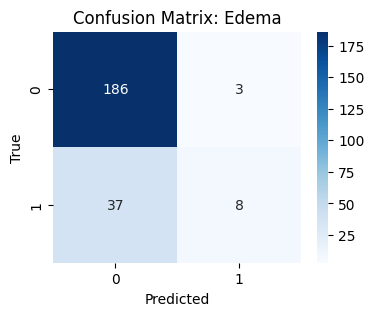

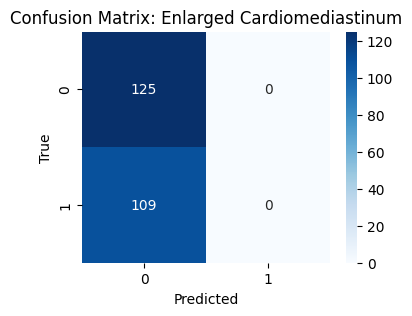

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


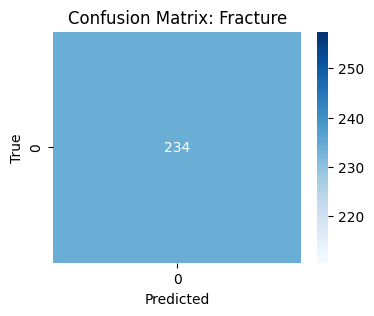

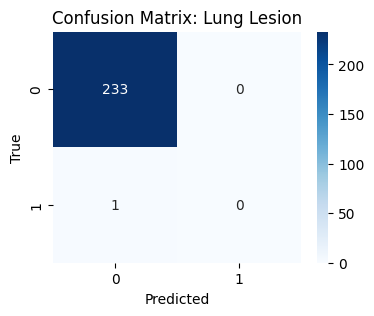

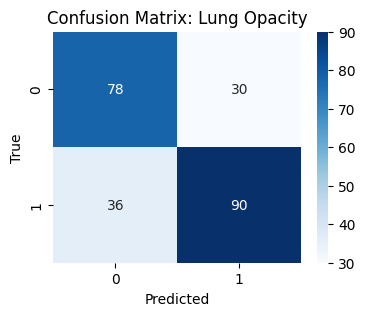

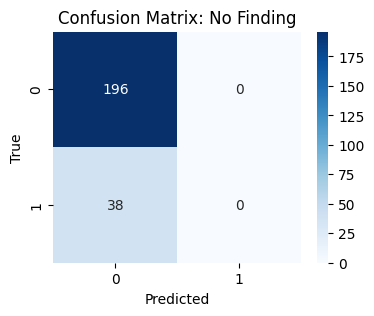

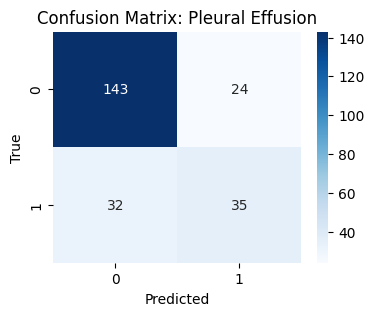

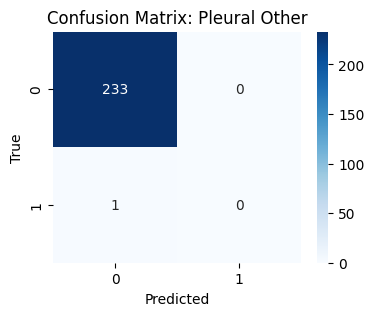

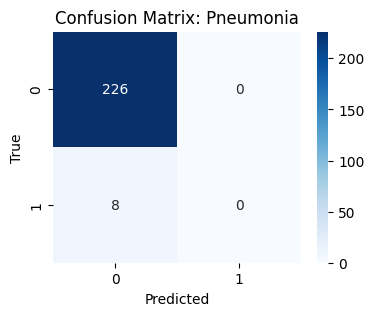

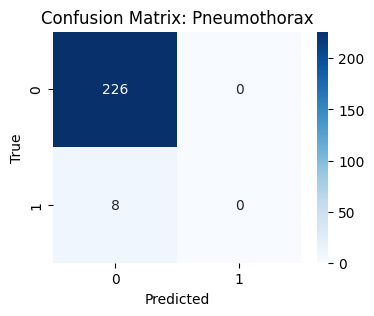

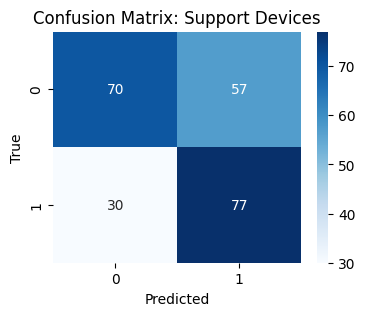

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds, targets = get_preds(model)

preds_bin = (preds > 0.5).astype(int)

for i in range(14):
    cm = confusion_matrix(targets[:, i], preds_bin[:, i])

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {label_values[i]}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

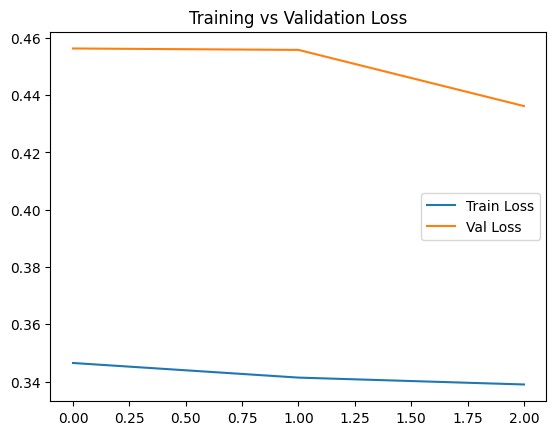

In [33]:
import matplotlib.pyplot as plt

train_losses = [0.3465, 0.3414, 0.3390]
val_losses   = [0.4563, 0.4558, 0.4362]

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [30]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generate_gradcam(model, image_tensor, target_layer):
    model.eval()

    gradients = []
    activations = []

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module, input, output):
        activations.append(output)

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)

    output = model(image_tensor)
    target_class = 0
    target = output[0][target_class]

    model.zero_grad()
    target.backward()

    grads = gradients[0].cpu().data.numpy()[0]
    acts = activations[0].cpu().data.numpy()[0]

    weights = np.mean(grads, axis=(1,2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224,224))
    cam = cam - np.min(cam)
    cam = cam / np.max(cam)

    handle_f.remove()
    handle_b.remove()

    return cam

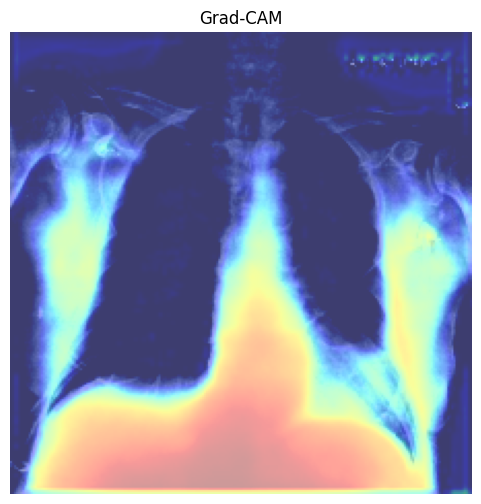

In [35]:
img, label = valid_dataset[0]

input_tensor = img.unsqueeze(0).to(device)

cam = generate_gradcam(model, input_tensor, model.conv[3])

img_np = img.permute(1,2,0).numpy()

plt.figure(figsize=(6,6))
plt.imshow(img_np, alpha=0.6)
plt.imshow(cam, cmap='jet', alpha=0.4)
plt.title("Grad-CAM")
plt.axis('off')
plt.show()

In [25]:
import os

print(os.listdir())

['.config', 'drive', 'chexpert', 'best_model_cnn.pth', 'sample_data']


In [27]:
import zipfile

with zipfile.ZipFile("models.zip", 'w') as zipf:
    zipf.write("best_model_cnn.pth")


In [28]:
from google.colab import files
files.download("models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metr

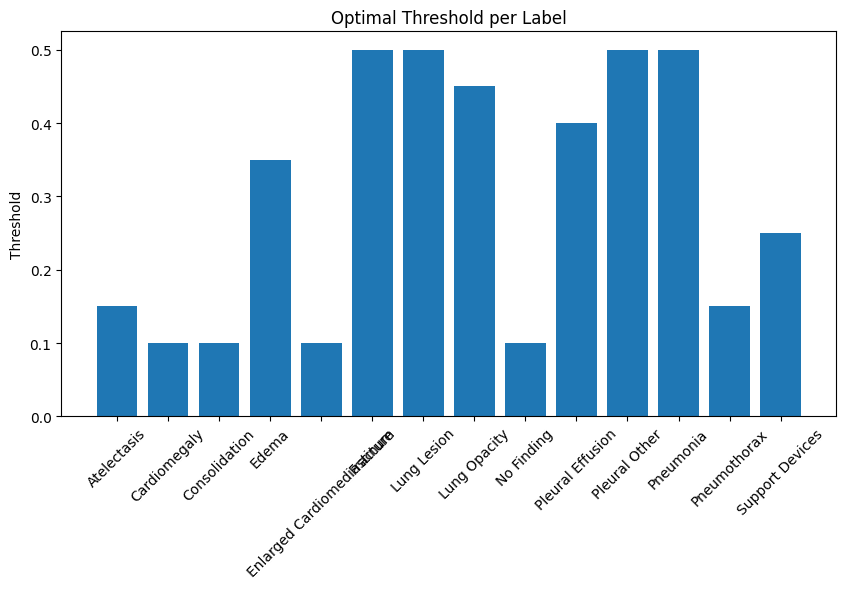

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions from the model
preds, targets = get_preds(model)

# Find optimal thresholds
thresholds = find_thresholds(preds, targets)

plt.figure(figsize=(10,5))
plt.bar(label_values, thresholds) # Use label_values for x-axis labels
plt.xticks(rotation=45)
plt.title("Optimal Threshold per Label")
plt.ylabel("Threshold")
plt.show()